In [13]:
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from pathlib import Path

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [15]:
with open('experiment_A_summary.json', 'r') as f:
    results = json.load(f)

# Print first result to see structure
print("First result structure:")
print(json.dumps(results[0], indent=2))

# Convert to pandas DataFrame for easier manipulation
df = pd.DataFrame(results)

# Print column names
print("\nAvailable columns:")
print(df.columns.tolist())

# Print available models
print("\nAvailable models:")
print(df['model'].tolist())


First result structure:
{
  "model": "resnet18",
  "dataset": "cifar10",
  "best_accuracy": 94.47,
  "params_m": 11.17,
  "flops_g": 0.56,
  "inference_time_bs1_ms": 1.21,
  "inference_time_bs128_ms": 13.03
}

Available columns:
['model', 'dataset', 'best_accuracy', 'params_m', 'flops_g', 'inference_time_bs1_ms', 'inference_time_bs128_ms']

Available models:
['resnet18', 'resnet18_swconv', 'convnext_tiny', 'repvgg_a0', 'mobilenetv3_small', 'efficientnet_b0']


In [16]:
if 'best_accuracy' in df.columns:
    acc_col = 'best_accuracy'
elif 'accuracy' in df.columns:
    acc_col = 'accuracy'
else:
    acc_col = 'Accuracy (%)' if 'Accuracy (%)' in df.columns else None

if 'params_m' in df.columns:
    params_col = 'params_m'
elif 'params (M)' in df.columns:
    params_col = 'params (M)'
else:
    params_col = 'Parameters (M)' if 'Parameters (M)' in df.columns else None

if 'flops_g' in df.columns:
    flops_col = 'flops_g'
elif 'FLOPs (G)' in df.columns:
    flops_col = 'FLOPs (G)'
else:
    flops_col = 'FLOPs (G)' if 'FLOPs (G)' in df.columns else None

if 'inference_time_bs128_ms' in df.columns:
    time_col = 'inference_time_bs128_ms'
elif 'inference BS128 (ms)' in df.columns:
    time_col = 'inference BS128 (ms)'
else:
    time_col = 'Inference BS128 (ms)' if 'Inference BS128 (ms)' in df.columns else None

# Rename columns for consistency
column_mapping = {}
if acc_col:
    column_mapping[acc_col] = 'Accuracy (%)'
if params_col:
    column_mapping[params_col] = 'Parameters (M)'
if flops_col:
    column_mapping[flops_col] = 'FLOPs (G)'
if time_col:
    column_mapping[time_col] = 'Inference BS128 (ms)'

df = df.rename(columns=column_mapping)

# Display the results
print("\nExperiment Results:")
print("="*80)
df_display = df[['model', 'Accuracy (%)', 'Parameters (M)', 'FLOPs (G)', 
                 'Inference BS128 (ms)']].copy()
df_display = df_display.sort_values('Accuracy (%)', ascending=False)
display(df_display)



Experiment Results:


,model,Accuracy (%),Parameters (M),FLOPs (G),Inference BS128 (ms)
1,resnet18_swconv,94.67,88.080000,5.750000,188.820000
0,resnet18,94.47,11.170000,0.560000,13.030000
3,repvgg_a0,93.44,2.958778,0.156191,5.292072
2,convnext_tiny,91.58,7.455690,0.376666,32.892764
5,efficientnet_b0,90.81,4.261654,0.027652,8.180399
4,mobilenetv3_small,74.43,0.909174,0.001579,2.909994


In [26]:
best_accuracy = df.loc[df['Accuracy (%)'].idxmax()]
most_efficient_params = df.loc[df['Parameters (M)'].idxmin()]
most_efficient_flops = df.loc[df['FLOPs (G)'].idxmin()]

print("**Key Findings:**")
print("="*60)
print(f"Best Accuracy: {best_accuracy['model']} - {best_accuracy['Accuracy (%)']:.2f}%")
print(f"Most Efficient (Parameters): {most_efficient_params['model']} - {most_efficient_params['Parameters (M)']:.2f}M params")
print(f"Most Efficient (FLOPs): {most_efficient_flops['model']} - {most_efficient_flops['FLOPs (G)']:.4f}G FLOPs")

# Check SW-Conv vs Baseline improvement
swconv_model = df[df['model'].str.contains('swconv', case=False, na=False)]
resnet_model = df[df['model'].str.contains('resnet18', case=False, na=False) & ~df['model'].str.contains('swconv', case=False, na=False)]

if not swconv_model.empty and not resnet_model.empty:
    improvement = swconv_model['Accuracy (%)'].values[0] - resnet_model['Accuracy (%)'].values[0]
    print(f"\nSW-Conv vs Baseline Improvement: +{improvement:.2f}%")
    print(f"  {swconv_model['model'].values[0]}: {swconv_model['Accuracy (%)'].values[0]:.2f}%")
    print(f"  {resnet_model['model'].values[0]}: {resnet_model['Accuracy (%)'].values[0]:.2f}%")
else:
    print("\nCould not find both SW-Conv and baseline models for comparison")


**Key Findings:**
Best Accuracy: resnet18_swconv - 94.67%
Most Efficient (Parameters): mobilenetv3_small - 0.91M params
Most Efficient (FLOPs): mobilenetv3_small - 0.0016G FLOPs

SW-Conv vs Baseline Improvement: +0.20%
  resnet18_swconv: 94.67%
  resnet18: 94.47%


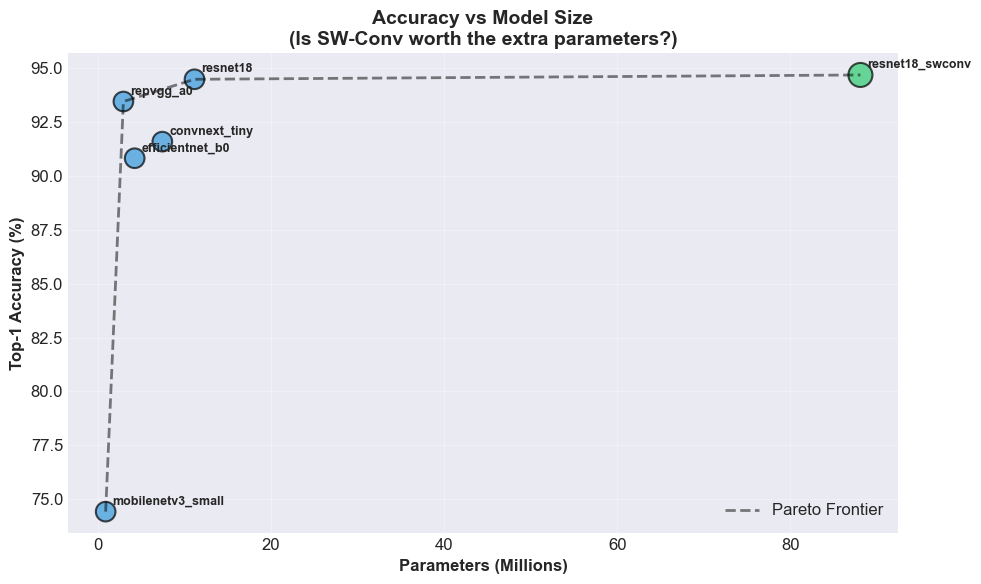

✓ Saved: results/plots/acc_vs_params.png


In [18]:
def plot_accuracy_vs_params(df):
    """Plot Accuracy vs Number of Parameters"""
    plt.figure(figsize=(10, 6))
    
    # Create scatter plot
    models = df['model'].values
    acc = df['Accuracy (%)'].values
    params = df['Parameters (M)'].values
    
    # Highlight SW-Conv
    colors = ['#2ecc71' if 'swconv' in str(m).lower() else '#3498db' for m in models]
    sizes = [300 if 'swconv' in str(m).lower() else 200 for m in models]
    
    plt.scatter(params, acc, s=sizes, c=colors, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    # Add labels
    for i, model in enumerate(models):
        plt.annotate(model, (params[i], acc[i]), xytext=(5, 5), 
                    textcoords='offset points', fontsize=9, fontweight='bold')
    
    plt.xlabel('Parameters (Millions)', fontsize=12, fontweight='bold')
    plt.ylabel('Top-1 Accuracy (%)', fontsize=12, fontweight='bold')
    plt.title('Accuracy vs Model Size\n(Is SW-Conv worth the extra parameters?)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Add Pareto frontier (approximate)
    # Sort by params and find non-dominated points
    sorted_idx = np.argsort(params)
    pareto_acc = []
    pareto_params = []
    max_acc = 0
    for i in sorted_idx:
        if acc[i] > max_acc:
            pareto_acc.append(acc[i])
            pareto_params.append(params[i])
            max_acc = acc[i]
    
    if len(pareto_acc) > 1:
        plt.plot(pareto_params, pareto_acc, 'k--', alpha=0.5, linewidth=2, label='Pareto Frontier')
        plt.legend(loc='lower right')
    
    plt.tight_layout()
    
    # Create directory if it doesn't exist
    Path('results/plots').mkdir(parents=True, exist_ok=True)
    plt.savefig('results/plots/acc_vs_params.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: results/plots/acc_vs_params.png")

plot_accuracy_vs_params(df)

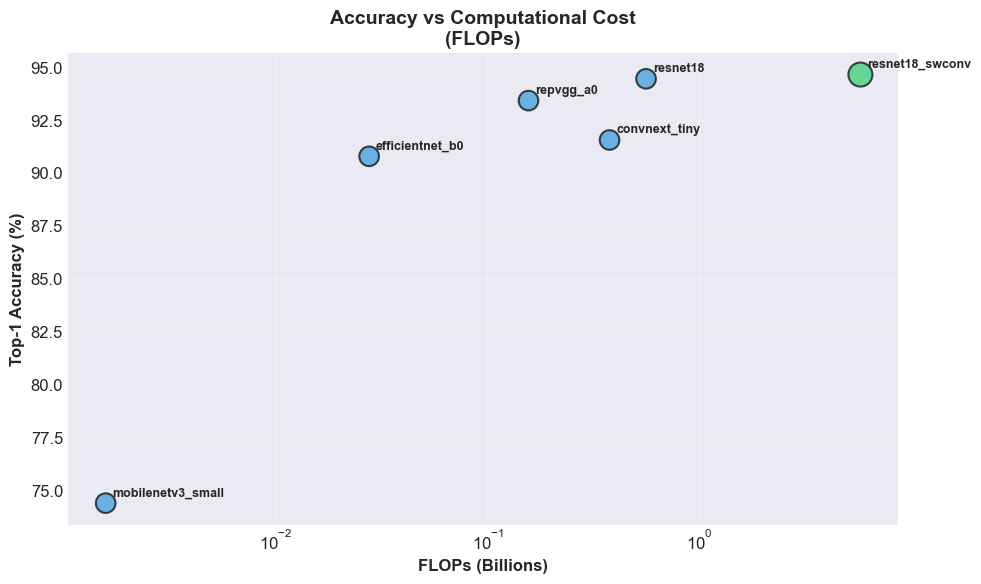

✓ Saved: results/plots/acc_vs_flops.png


In [20]:
def plot_accuracy_vs_flops(df):
    """Plot Accuracy vs FLOPs"""
    plt.figure(figsize=(10, 6))
    
    models = df['model'].values
    acc = df['Accuracy (%)'].values
    flops = df['FLOPs (G)'].values
    
    colors = ['#2ecc71' if 'swconv' in str(m).lower() else '#3498db' for m in models]
    sizes = [300 if 'swconv' in str(m).lower() else 200 for m in models]
    
    plt.scatter(flops, acc, s=sizes, c=colors, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    for i, model in enumerate(models):
        plt.annotate(model, (flops[i], acc[i]), xytext=(5, 5), 
                    textcoords='offset points', fontsize=9, fontweight='bold')
    
    plt.xlabel('FLOPs (Billions)', fontsize=12, fontweight='bold')
    plt.ylabel('Top-1 Accuracy (%)', fontsize=12, fontweight='bold')
    plt.title('Accuracy vs Computational Cost\n(FLOPs)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    flops_for_log = [max(f, 0.001) for f in flops]
    plt.xscale('log')
    
    plt.tight_layout()
    plt.savefig('results/plots/acc_vs_flops.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: results/plots/acc_vs_flops.png")

plot_accuracy_vs_flops(df)

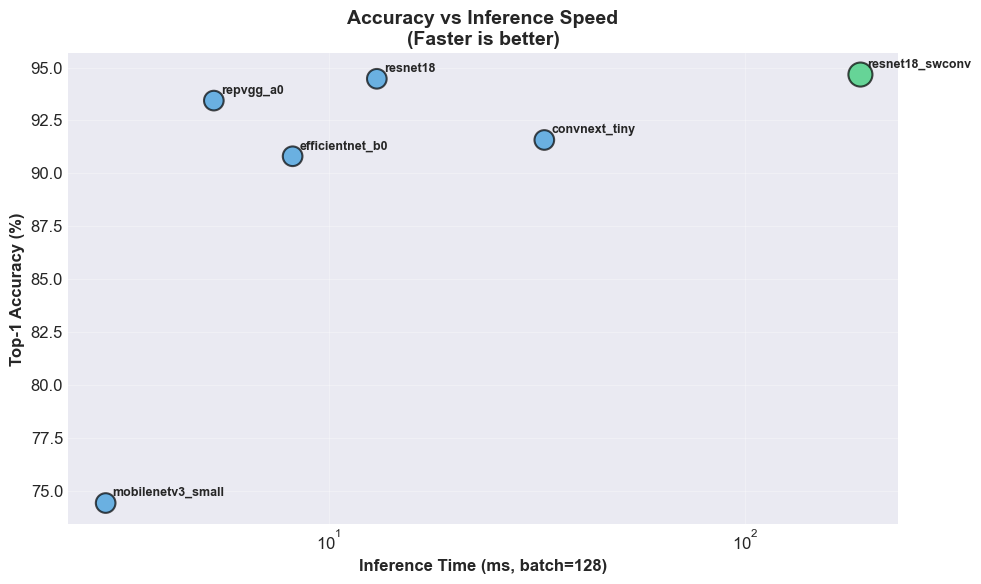

✓ Saved: results/plots/acc_vs_inference.png


In [21]:
def plot_accuracy_vs_inference(df):
    """Plot Accuracy vs Inference Time (batch=128)"""
    plt.figure(figsize=(10, 6))
    
    models = df['model'].values
    acc = df['Accuracy (%)'].values
    inference_time = df['Inference BS128 (ms)'].values
    
    colors = ['#2ecc71' if 'swconv' in str(m).lower() else '#3498db' for m in models]
    sizes = [300 if 'swconv' in str(m).lower() else 200 for m in models]
    
    plt.scatter(inference_time, acc, s=sizes, c=colors, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    for i, model in enumerate(models):
        plt.annotate(model, (inference_time[i], acc[i]), xytext=(5, 5), 
                    textcoords='offset points', fontsize=9, fontweight='bold')
    
    plt.xlabel('Inference Time (ms, batch=128)', fontsize=12, fontweight='bold')
    plt.ylabel('Top-1 Accuracy (%)', fontsize=12, fontweight='bold')
    plt.title('Accuracy vs Inference Speed\n(Faster is better)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Log scale for inference time
    plt.xscale('log')
    
    plt.tight_layout()
    plt.savefig('results/plots/acc_vs_inference.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: results/plots/acc_vs_inference.png")

plot_accuracy_vs_inference(df)

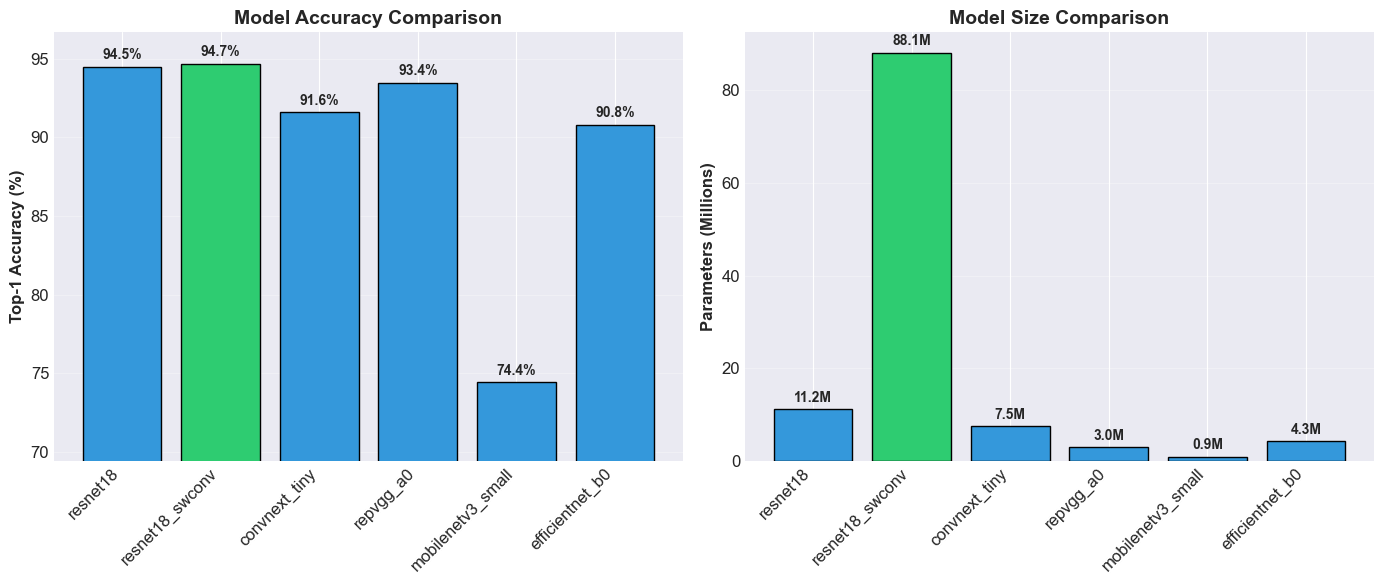

✓ Saved: results/plots/comparison_bars.png


In [22]:
def plot_comparison_bars(df):
    """Create side-by-side bar charts for accuracy and parameters"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    models = df['model'].values
    acc = df['Accuracy (%)'].values
    params = df['Parameters (M)'].values
    
    # Colors: highlight SW-Conv in green
    colors = ['#2ecc71' if 'swconv' in str(m).lower() else '#3498db' for m in models]
    
    # Accuracy bar chart
    bars1 = axes[0].bar(models, acc, color=colors, edgecolor='black', linewidth=1)
    axes[0].set_ylabel('Top-1 Accuracy (%)', fontsize=12, fontweight='bold')
    axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
    axes[0].set_ylim([min(acc)-5, max(acc)+2])
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars1, acc):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Parameters bar chart
    bars2 = axes[1].bar(models, params, color=colors, edgecolor='black', linewidth=1)
    axes[1].set_ylabel('Parameters (Millions)', fontsize=12, fontweight='bold')
    axes[1].set_title('Model Size Comparison', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars2, params):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{val:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('results/plots/comparison_bars.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: results/plots/comparison_bars.png")

plot_comparison_bars(df)


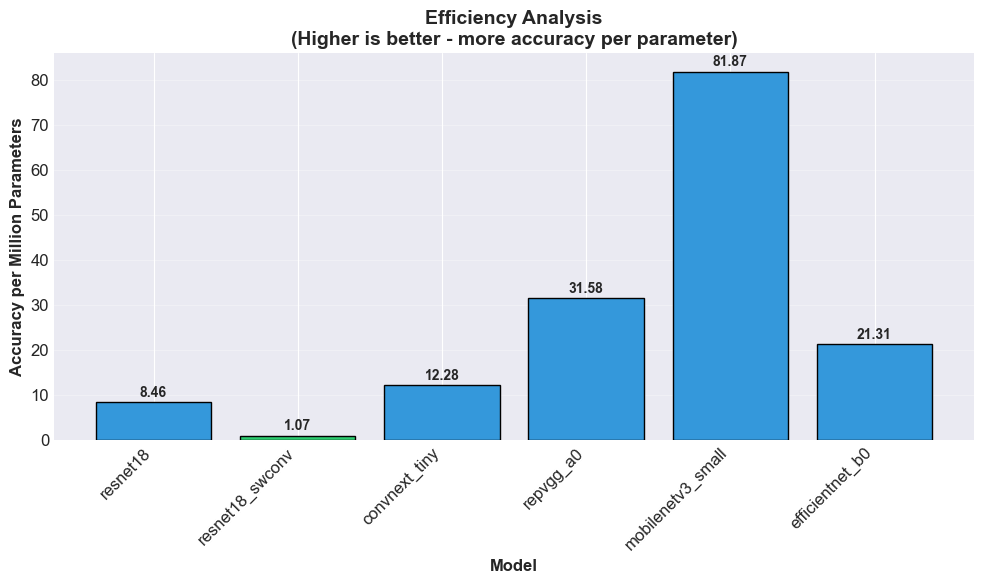

✓ Saved: results/plots/efficiency_analysis.png


In [23]:
def plot_efficiency_analysis(df):
    """Plot accuracy per parameter (efficiency metric)"""
    plt.figure(figsize=(10, 6))
    
    models = df['model'].values
    acc = df['Accuracy (%)'].values
    params = df['Parameters (M)'].values
    
    # Calculate efficiency (accuracy per million parameters)
    efficiency = acc / params
    
    colors = ['#2ecc71' if 'swconv' in str(m).lower() else '#3498db' for m in models]
    bars = plt.bar(models, efficiency, color=colors, edgecolor='black', linewidth=1)
    
    plt.ylabel('Accuracy per Million Parameters', fontsize=12, fontweight='bold')
    plt.xlabel('Model', fontsize=12, fontweight='bold')
    plt.title('Efficiency Analysis\n(Higher is better - more accuracy per parameter)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, val in zip(bars, efficiency):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('results/plots/efficiency_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: results/plots/efficiency_analysis.png")

plot_efficiency_analysis(df)